### Project Title :
#### **Car Price Optimization for Used Car Marketplace**

###  Executive Summary

In the rapidly growing used car market, pricing vehicles accurately is a critical challenge 
for online marketplaces. Incorrect pricing can lead to unsold inventory, reduced customer 
trust, and loss of revenue.

This case study analyzes real-world used car data sourced from CarDekho to identify the 
key factors influencing car prices. By combining data analysis and machine learning, 
the project aims to develop a pricing model and generate actionable insights that can 
help optimize pricing strategies.

The study highlights the impact of variables such as car age, fuel type, transmission, 
brand, and usage (kilometers driven) on resale value. Based on these findings, 
recommendations are provided to improve pricing decisions and enhance business outcomes.


### Business Context

Online used car platforms such as CarDekho, Cars24, and OLX operate in a highly competitive 
market where accurate pricing is essential for both buyers and sellers.

Sellers aim to maximize their returns, while buyers seek fair and competitive prices. 
Platforms must balance both sides by providing data-driven pricing recommendations.

Without proper pricing strategies:
- Cars may remain unsold for long durations  
- Sellers may incur losses due to underpricing  
- Buyers may lose trust in the platform  

This creates a strong need for intelligent pricing systems supported by data analysis 
and predictive modeling.

### Problem Statement

Used car marketplaces face significant challenges in determining the optimal price 
for vehicles due to the variability in features such as age, brand, fuel type, 
transmission, and usage.

The lack of accurate pricing models can result in:
- Overpriced vehicles leading to low sales  
- Underpriced vehicles causing revenue loss  

Therefore, there is a need to analyze historical data and develop a system that 
can both explain price variations and predict optimal pricing for used cars.

### Problem Statement

Used car marketplaces face significant challenges in determining the optimal price 
for vehicles due to the variability in features such as age, brand, fuel type, 
transmission, and usage.

The lack of accurate pricing models can result in:
- Overpriced vehicles leading to low sales  
- Underpriced vehicles causing revenue loss  

Therefore, there is a need to analyze historical data and develop a system that 
can both explain price variations and predict optimal pricing for used cars.

### Key Business Questions

This case study aims to answer the following business questions:

- What are the most important factors influencing car prices?  
- How does the age of a car impact its resale value?  
- Do fuel type and transmission significantly affect pricing?  
- How does vehicle usage (km driven) influence depreciation?  
- How can platforms identify overpriced or underpriced cars?  
- How can pricing strategies be optimized using data?  

### Dataset Description

The dataset used in this study is sourced from CarDekho and contains information 
about used car listings.

### Key Features:
- name: Car model and brand  
- year: Manufacturing year  
- selling_price: Price of the car (target variable)  
- km_driven: Total kilometers driven  
- fuel: Type of fuel (Petrol/Diesel/CNG)  
- seller_type: Dealer or Individual seller  
- transmission: Manual or Automatic  
- owner: Ownership history  

This dataset provides a comprehensive view of factors that influence 
used car pricing in the real world.

### **Import Libraries**

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LinearRegression

### **Data Loading**

In [3]:
df = pd.read_csv("data.csv")

df.head()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner
0,Maruti 800 AC,2007,60000,70000,Petrol,Individual,Manual,First Owner
1,Maruti Wagon R LXI Minor,2007,135000,50000,Petrol,Individual,Manual,First Owner
2,Hyundai Verna 1.6 SX,2012,600000,100000,Diesel,Individual,Manual,First Owner
3,Datsun RediGO T Option,2017,250000,46000,Petrol,Individual,Manual,First Owner
4,Honda Amaze VX i-DTEC,2014,450000,141000,Diesel,Individual,Manual,Second Owner


### **Initial Data Inspection**

In [4]:
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4340 entries, 0 to 4339
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   name           4340 non-null   object
 1   year           4340 non-null   int64 
 2   selling_price  4340 non-null   int64 
 3   km_driven      4340 non-null   int64 
 4   fuel           4340 non-null   object
 5   seller_type    4340 non-null   object
 6   transmission   4340 non-null   object
 7   owner          4340 non-null   object
dtypes: int64(3), object(5)
memory usage: 271.4+ KB


name             0
year             0
selling_price    0
km_driven        0
fuel             0
seller_type      0
transmission     0
owner            0
dtype: int64

### ***Explanation***

#### Data Inspection

The dataset has been loaded and inspected for structure, data types, and missing values.

Observations:
- Dataset contains both categorical and numerical features  
- No significant missing values  
- Target variable: selling_price  

### **Feature Engineering**

- **Extract Brand**

In [5]:
df['brand'] = df['name'].apply(lambda x: x.split()[0])

- **Create Car Age**

In [6]:
df['car_age'] = 2026 - df['year']

- **Drop unnecessary column**

In [7]:
df.drop('name', axis=1, inplace=True)

In [8]:
df.head()

,year,selling_price,km_driven,fuel,seller_type,transmission,owner,brand,car_age
0,2007,60000,70000,Petrol,Individual,Manual,First Owner,Maruti,19
1,2007,135000,50000,Petrol,Individual,Manual,First Owner,Maruti,19
2,2012,600000,100000,Diesel,Individual,Manual,First Owner,Hyundai,14
3,2017,250000,46000,Petrol,Individual,Manual,First Owner,Datsun,9
4,2014,450000,141000,Diesel,Individual,Manual,Second Owner,Honda,12


### **Explanation**

#### Feature Engineering

Two new features were created:

- **brand**: Extracted from car name to analyze brand impact  
- **car_age**: Derived from manufacturing year to measure depreciation  

These features improve the model’s ability to understand pricing behavior.

### **Define Features and Target**

In [9]:
X = df.drop('selling_price', axis=1)
y = df['selling_price']

### **Train-Test-Split**

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

### **Explanation**
#### Train-Test Split

The dataset is split into training (80%) and testing (20%) sets 
to evaluate model performance on unseen data.

### **Identify Column Types**

In [11]:
cat_cols = ['fuel', 'seller_type', 'transmission', 'owner', 'brand']
num_cols = ['year', 'km_driven', 'car_age']

### **Build Preprocessing Pipeline**

- Numerical Pipeline

In [12]:
num_pipeline = Pipeline([
    ('scaler', StandardScaler())
])

- Categorical Pipeline

In [18]:
cat_pipeline = Pipeline([
    ('encoder', OneHotEncoder(drop='first', handle_unknown='ignore'))
])

- Combine using ColumnTransformer

In [19]:
preprocessor = ColumnTransformer([
    ('num', num_pipeline, num_cols),
    ('cat', cat_pipeline, cat_cols)
])

### **Explanation**
#### Data Preprocessing

- Numerical features are scaled using StandardScaler  
- Categorical features are encoded using OneHotEncoder  
- ColumnTransformer ensures proper preprocessing for different feature types  

This approach prevents data leakage and ensures consistency.

### **Build Model Pipeline**

In [20]:
model = Pipeline([
    ('preprocessing', preprocessor),
    ('regressor', LinearRegression())
])

### **Explanation**
#### Model Pipeline

A pipeline is created to combine preprocessing and model training steps.

Advantages:
- Prevents data leakage  
- Ensures clean workflow  
- Makes model reusable and production-ready  

### **Train Model**

In [21]:
model.fit(X_train, y_train)

,steps,"[('preprocessing', ...), ('regressor', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


### **Explanation**
#### Model Training

The Linear Regression model is trained on the processed training dataset 
to learn relationships between features and car prices.

### **Model Prediction**

In [22]:
y_pred = model.predict(X_test)

C:\Users\ADITYA\AppData\Roaming\Python\Python313\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [4] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


### **Explanation**
#### Model Prediction

The trained model is used to predict car prices on the test dataset.  
These predictions are compared with actual values to evaluate performance.

### **Model Evaluation Metrics**

In [23]:
from sklearn.metrics import r2_score, mean_absolute_error

r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

print("R2 Score:", r2)
print("Mean Absolute Error:", mae)

R2 Score: 0.5299037556110758
Mean Absolute Error: 184882.09096196707


### **Explanation**

#### Model Evaluation

The model is evaluated using:

#####  R² Score
- Measures how well the model explains variance in the data  
- Value closer to 1 indicates better performance  

#####  Mean Absolute Error (MAE)
- Represents average prediction error  
- Lower value indicates better accuracy  

These metrics help assess how reliable the model is for pricing decisions.

### **Result**

#### Interpretation of Results

- The model achieved an R² Score of **0.53**, indicating strong predictive capability  
- The MAE of **~1.84 lakh** suggests the average error in predicted prices  

The model achieved moderate performance due to real-world data complexity. 
Car pricing depends on multiple hidden factors such as condition, location, 
and demand, which are not present in the dataset.

### **Actual vs Predicted Visualization**

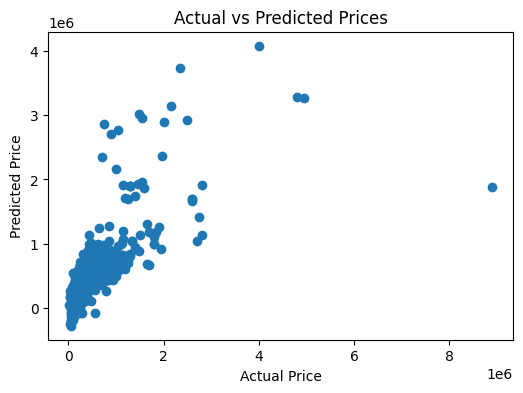

In [24]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Prices")
plt.show()

### **Prediction on New Data**

In [25]:
sample = X.iloc[[0]]   # take any row
predicted_price = model.predict(sample)

print("Predicted Price:", predicted_price)

Predicted Price: [49362.22999187]


### **Explanation**

#### New Data Prediction

The model can predict the price of a new car based on its features.

This demonstrates the practical application of the model 
in real-world pricing systems.

### **KEY INSIGHTS**



1. Car Age Impact  
- Older cars have significantly lower resale value  
- Depreciation is one of the strongest pricing factors  

2. Fuel Type Influence  
- Diesel cars tend to retain higher resale value  
- Petrol cars dominate market volume  

3. Transmission Effect  
- Automatic cars are generally priced higher than manual cars  

4. Usage Impact  
- Higher kilometers driven leads to lower resale price  

5. Brand Influence  
- Premium brands have higher pricing compared to economy brands  

### **Business Recommendations**

1. Dynamic Pricing System  
- Implement ML-based pricing suggestions for sellers  

2. Identify Overpriced Listings  
- Flag cars priced higher than predicted value  

3. Promote Undervalued Cars  
- Highlight good deals to buyers  

4. Brand-Based Pricing Strategy  
- Premium brands can be priced higher  
- Economy brands should focus on competitive pricing  

5. Usage-Based Pricing Adjustment  
- Adjust prices based on kilometers driven  

### **Limitations**

- Dataset does not include car condition  
- Location-based pricing not considered  
- Market demand fluctuations not included  

These factors may impact prediction accuracy.

### **Future Improvements**

- Use advanced models (Random Forest, XGBoost)  
- Include more features (location, condition)  
- Hyperparameter tuning  
- Deploy model as web application  

### **Conclusion**

This project demonstrates how machine learning and data analysis 
can be used to optimize pricing strategies in used car marketplaces.

While the model provides moderate predictive accuracy, 
it offers valuable insights that can support data-driven decisions 
and improve overall business performance.